# Problema 2 - Regresion: Estimacion de Edad a partir de Imagenes Faciales




## Estructura esperada

El notebook puede encontrar el dataset de dos maneras:

1. **Ruta local**: si extrajiste el dataset en alguna de estas rutas:
   - `regresion/data/faces_age_detection/`
   - `regresion/data/`
2. **Descarga automatica**: si no encuentra imagenes locales, intentara descargar el dataset con `kagglehub` usando:
   `arashnic/faces-age-detection-dataset`

El notebook asume que la version de regresion del dataset usa imagenes estilo **UTKFace**, donde la edad esta embebida en el nombre del archivo con un formato como:

`[age]_[gender]_[race]_[timestamp].jpg`

Ejemplo: `25_0_2_20170116174525125.jpg`


In [12]:
from pathlib import Path
import re
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms

from PIL import Image, ImageStat
from IPython.display import display
from tqdm.auto import tqdm

try:
    import kagglehub
except ImportError:
    kagglehub = None

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
random_state = 42
rng = np.random.default_rng(random_state)


In [2]:

IMAGE_SUFFIXES = {'.jpg', '.jpeg', '.png'}
UTKFACE_PATTERN = re.compile(
    r'^(?P<age>\d+)_(?P<gender>[01])_(?P<race>[0-4])_(?P<timestamp>\d+)\.(jpg|jpeg|png)$',
    re.IGNORECASE,
)


def resolve_paths():
    cwd = Path.cwd().resolve()
    if cwd.name == 'regresion':
        notebook_dir = cwd
        project_root = cwd.parent
    elif (cwd / 'regresion').exists():
        project_root = cwd
        notebook_dir = cwd / 'regresion'
    else:
        notebook_dir = cwd
        project_root = cwd.parent
    return project_root, notebook_dir



def collect_image_files(base_path):
    if base_path is None or not Path(base_path).exists():
        return []
    return sorted(
        [path for path in Path(base_path).rglob('*') if path.suffix.lower() in IMAGE_SUFFIXES]
    )



def filter_utkface_files(paths):
    return [path for path in paths if UTKFACE_PATTERN.match(path.name)]


project_root, notebook_dir = resolve_paths()

preferred_utkface_dirs = [
    notebook_dir / 'data' / 'archive' / 'faces_02' / 'part3',
    project_root / 'regresion' / 'data' / 'archive' / 'faces_02' / 'part3',
    notebook_dir / 'data' / 'faces_age_detection',
    project_root / 'regresion' / 'data' / 'faces_age_detection',
]

fallback_roots = [
    notebook_dir / 'data',
    project_root / 'regresion' / 'data',
]

source_mode = None
dataset_dir = None
image_files = []

for candidate in preferred_utkface_dirs:
    candidate_files = filter_utkface_files(collect_image_files(candidate))
    if candidate_files:
        dataset_dir = candidate
        image_files = candidate_files
        source_mode = 'local_utkface'
        break

if not image_files:
    for root in fallback_roots:
        candidate_files = filter_utkface_files(collect_image_files(root))
        if candidate_files:
            dataset_dir = root
            image_files = candidate_files
            source_mode = 'local_recursive_utkface'
            break

if not image_files and kagglehub is not None:
    dataset_dir = Path(kagglehub.dataset_download('arashnic/faces-age-detection-dataset'))
    image_files = filter_utkface_files(collect_image_files(dataset_dir))
    if image_files:
        source_mode = 'kagglehub_utkface'

if not image_files:
    raise FileNotFoundError(
        'No se encontraron imagenes con patron UTKFace. '        'Para este problema de regresion se necesitan nombres tipo 25_0_2_20170116174525125.jpg. '        'La carpeta faces/Train con archivos como 123.jpg no sirve para regresion de edad continua.'
    )

print(f'Project root: {project_root}')
print(f'Notebook dir: {notebook_dir}')
print(f'Dataset source: {source_mode}')
print(f'Dataset dir detectado: {dataset_dir}')
print(f'Total de imagenes UTKFace encontradas: {len(image_files):,}')


Project root: C:\Users\lalai\OneDrive\Desktop\IA\workshop2_ia
Notebook dir: C:\Users\lalai\OneDrive\Desktop\IA\workshop2_ia\regresion
Dataset source: local_recursive_utkface
Dataset dir detectado: C:\Users\lalai\OneDrive\Desktop\IA\workshop2_ia\regresion\data
Total de imagenes UTKFace encontradas: 24,101


## 1.0 Analisis preliminar del problema

Este es un problema de **regresion** porque la variable objetivo no es una clase discreta, sino una cantidad numerica: la **edad** de la persona en anios. El modelo no debe decir solo si la persona es joven o adulta, sino estimar un valor continuo aproximado.

- **Target:** edad del sujeto, medida en anios.
- **Inputs:** imagenes faciales.
- **Objetivo del modelo futuro:** predecir la edad a partir de los pixeles.
        


In [3]:
def parse_face_metadata(path):
    match = UTKFACE_PATTERN.match(path.name)
    if match:
        info = match.groupdict()
        return {
            'path': path,
            'filename': path.name,
            'age': int(info['age']),
            'gender': int(info['gender']),
            'race': int(info['race']),
            'timestamp': info['timestamp'],
            'parsed_with_utkface_pattern': True,
        }

    first_token = path.stem.split('_')[0]
    inferred_age = int(first_token) if first_token.isdigit() else np.nan
    return {
        'path': path,
        'filename': path.name,
        'age': inferred_age,
        'gender': np.nan,
        'race': np.nan,
        'timestamp': None,
        'parsed_with_utkface_pattern': False,
    }


faces_df = pd.DataFrame([parse_face_metadata(path) for path in image_files])
faces_df = faces_df.dropna(subset=['age']).copy()
faces_df['age'] = faces_df['age'].astype(int)
faces_df['gender_label'] = faces_df['gender'].map({0: 'Male', 1: 'Female'})
faces_df['race_label'] = faces_df['race'].map(
    {0: 'White', 1: 'Black', 2: 'Asian', 3: 'Indian', 4: 'Other'}
)

print(f'Total de registros con edad util: {len(faces_df):,}')
print(f'Porcentaje parseado con patron UTKFace: {faces_df["parsed_with_utkface_pattern"].mean() * 100:.2f}%')
display(faces_df.head())
        


Total de registros con edad util: 24,101
Porcentaje parseado con patron UTKFace: 100.00%


,path,filename,age,gender,race,timestamp,parsed_with_utkface_pattern,gender_label,race_label
0,C:\Users\lalai\OneDrive\Desktop\IA\workshop2_i...,100_1_0_20170110183726390.jpg,100,1,0,20170110183726390,True,Female,White
1,C:\Users\lalai\OneDrive\Desktop\IA\workshop2_i...,100_1_2_20170105174847679.jpg,100,1,2,20170105174847679,True,Female,Asian
2,C:\Users\lalai\OneDrive\Desktop\IA\workshop2_i...,100_1_2_20170110182836729.jpg,100,1,2,20170110182836729,True,Female,Asian
3,C:\Users\lalai\OneDrive\Desktop\IA\workshop2_i...,101_1_2_20170105174739309.jpg,101,1,2,20170105174739309,True,Female,Asian
4,C:\Users\lalai\OneDrive\Desktop\IA\workshop2_i...,10_0_0_20161220222308131.jpg,10,0,0,20161220222308131,True,Male,White


### Protocolo de adquisicion / generacion de los datos

La version de Kaggle `Faces: Age Detection from Images` utilizada para regresion se presenta como una adaptacion basada en **UTKFace**. La documentacion publica de UTKFace describe un conjunto con las siguientes caracteristicas:

- mas de 20 mil rostros "in the wild"
- una sola cara por imagen
- rango amplio de edades, de `0` a `116`
- etiquetas incluidas en el nombre del archivo
- variacion en pose, iluminacion, expresion, oclusiones y calidad visual


El dataset no proviene de fotos tomadas bajo condiciones de laboratorio totalmente controladas, sino de rostros en condiciones variadas del mundo real. Eso hace el problema mas realista, pero tambien mas dificil.

Fuentes utiles para documentar esta parte:

- Kaggle: `https://www.kaggle.com/datasets/arashnic/faces-age-detection-dataset`
- UTKFace oficial: `https://github.com/aicip/UTKFace`
        


In [4]:
def extract_image_properties(path):
    try:
        with Image.open(path) as image:
            rgb_image = image.convert('RGB')
            gray_image = rgb_image.convert('L')
            stat = ImageStat.Stat(gray_image)
            return {
                'path': path,
                'width': rgb_image.width,
                'height': rgb_image.height,
                'mode': image.mode,
                'channels': len(rgb_image.getbands()),
                'brightness_mean': stat.mean[0],
                'brightness_std': stat.stddev[0],
                'is_corrupted': False,
            }
    except Exception:
        return {
            'path': path,
            'width': np.nan,
            'height': np.nan,
            'mode': None,
            'channels': np.nan,
            'brightness_mean': np.nan,
            'brightness_std': np.nan,
            'is_corrupted': True,
        }


image_properties = pd.DataFrame(
    [extract_image_properties(path) for path in tqdm(faces_df['path'], desc='Leyendo propiedades de imagen')]
)
faces_df = faces_df.merge(image_properties, on='path', how='left')
faces_df['aspect_ratio'] = faces_df['width'] / faces_df['height']

print(f'Imagenes corruptas detectadas: {int(faces_df["is_corrupted"].sum())}')
        


Leyendo propiedades de imagen: 100%|██████████| 24101/24101 [07:38<00:00, 52.60it/s]


Imagenes corruptas detectadas: 0


In [5]:
input_summary = pd.DataFrame(
    {
        'metric': [
            'total_images',
            'min_age',
            'max_age',
            'mean_age',
            'median_age',
            'unique_sizes',
            'most_common_mode',
            'most_common_channels',
        ],
        'value': [
            len(faces_df),
            faces_df['age'].min(),
            faces_df['age'].max(),
            round(faces_df['age'].mean(), 2),
            faces_df['age'].median(),
            faces_df[['width', 'height']].drop_duplicates().shape[0],
            faces_df['mode'].mode().iat[0],
            int(faces_df['channels'].mode().iat[0]),
        ],
    }
)

display(input_summary)
print('\nResumen de tamanos mas frecuentes:')
display(
    faces_df.groupby(['width', 'height']).size().reset_index(name='count').sort_values('count', ascending=False).head(10)
)
        


,metric,value
0,total_images,24101
1,min_age,1
2,max_age,116
3,mean_age,33.04
4,median_age,29.0
5,unique_sizes,7622
6,most_common_mode,RGB
7,most_common_channels,3



Resumen de tamanos mas frecuentes:


,width,height,count
5729,738,1103,659
3191,452,451,544
6359,906,903,520
6980,1106,735,351
2408,368,551,343
7195,1206,675,307
6830,1042,779,274
5469,690,1015,261
5967,782,1039,212
6105,810,1007,178


## 2.0 Analisis exploratorio de datos (EDA)

En esta parte se busca responder preguntas como:

- como se distribuye la edad en el dataset
- si hay sesgo hacia ciertos rangos etarios
- como lucen las imagenes representativas
- si las imagenes cambian en brillo, calidad, tamano o formato

Todo esto importa porque un modelo de regresion puede sesgarse si casi todas las muestras estan concentradas en ciertos rangos de edad o si las imagenes son demasiado heterogeneas.
        


,age
count,24101.00
mean,33.04
std,20.14
min,1.00
25%,23.00
50%,29.00
75%,45.00
max,116.00


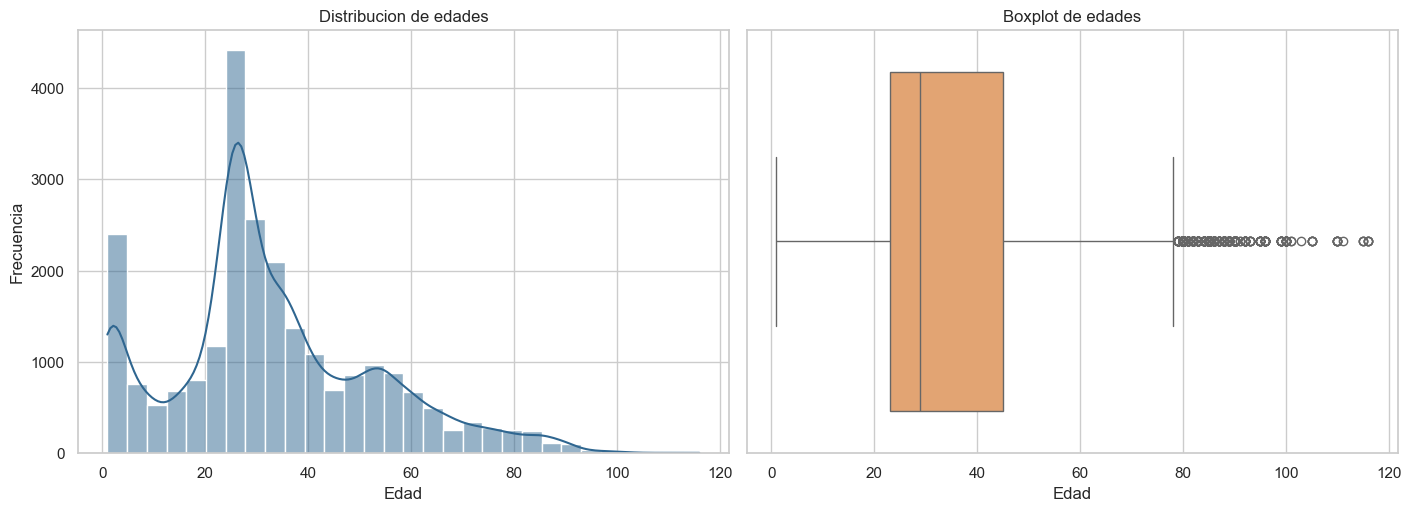

In [6]:
age_desc = faces_df['age'].describe().to_frame(name='age').round(2)
display(age_desc)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

sns.histplot(faces_df['age'], bins=30, kde=True, ax=axes[0], color='#2f6690')
axes[0].set_title('Distribucion de edades')
axes[0].set_xlabel('Edad')
axes[0].set_ylabel('Frecuencia')

sns.boxplot(x=faces_df['age'], ax=axes[1], color='#f4a261')
axes[1].set_title('Boxplot de edades')
axes[1].set_xlabel('Edad')

plt.show()
        


In [21]:
q1 = faces_df['age'].quantile(0.25)
q3 = faces_df['age'].quantile(0.75)
most_common_age = faces_df['age'].mode().iat[0]

print('Interpretacion de la distribucion de edades:')
print(f'- La edad minima es {faces_df["age"].min()} y la maxima es {faces_df["age"].max()}.')
print(f'- La media es {faces_df["age"].mean():.2f} y la mediana es {faces_df["age"].median():.2f}.')
print(f'- El rango intercuartil va de {q1:.2f} a {q3:.2f} anios.')
print(f'- La edad mas frecuente es {most_common_age} anios.')
print('- Si el histograma muestra picos en edades intermedias, eso puede generar sesgo del modelo hacia esos rangos.')
        


Interpretacion de la distribucion de edades:
- La edad minima es 1 y la maxima es 116.
- La media es 40.56 y la mediana es 35.00.
- El rango intercuartil va de 26.00 a 53.00 anios.
- La edad mas frecuente es 26 anios.
- Si el histograma muestra picos en edades intermedias, eso puede generar sesgo del modelo hacia esos rangos.


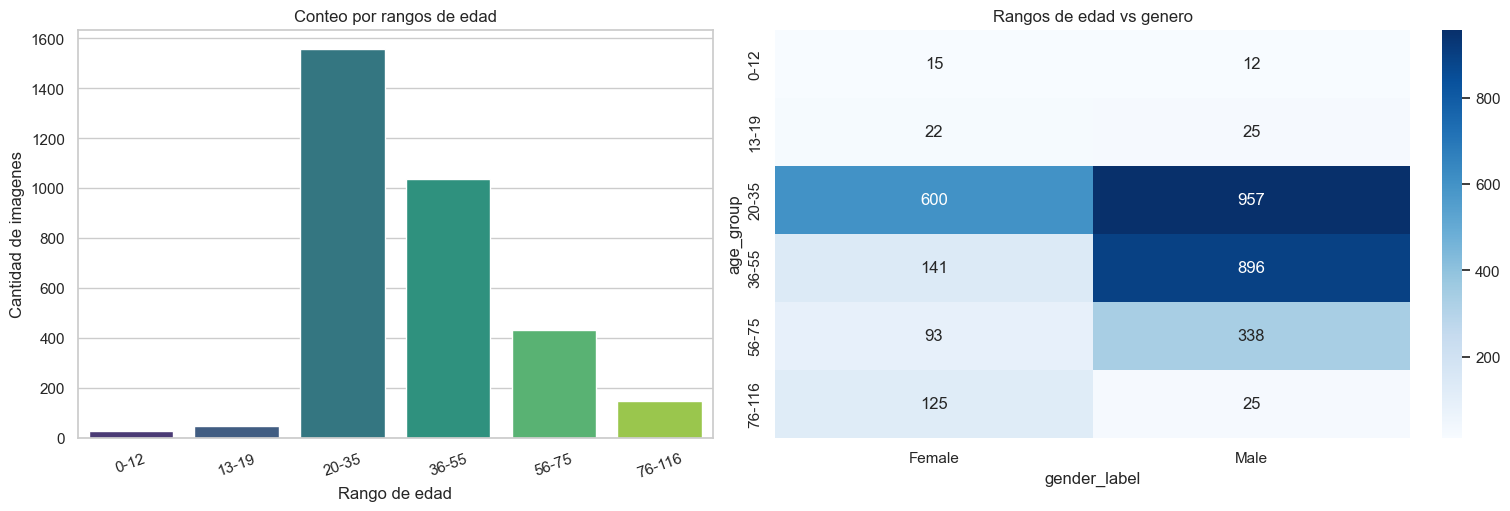

In [22]:
age_bins = [-1, 12, 19, 35, 55, 75, 116]
age_labels = ['0-12', '13-19', '20-35', '36-55', '56-75', '76-116']
faces_df['age_group'] = pd.cut(faces_df['age'], bins=age_bins, labels=age_labels)

fig, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)

age_group_counts = faces_df['age_group'].value_counts().sort_index()
sns.barplot(x=age_group_counts.index, y=age_group_counts.values, ax=axes[0], palette='viridis')
axes[0].set_title('Conteo por rangos de edad')
axes[0].set_xlabel('Rango de edad')
axes[0].set_ylabel('Cantidad de imagenes')
axes[0].tick_params(axis='x', rotation=20)

if faces_df['gender_label'].notna().any():
    gender_age = pd.crosstab(faces_df['age_group'], faces_df['gender_label'])
    sns.heatmap(gender_age, annot=True, fmt='d', cmap='Blues', ax=axes[1])
    axes[1].set_title('Rangos de edad vs genero')
else:
    axes[1].axis('off')

plt.show()
        


In [23]:
major_group = age_group_counts.idxmax()
minor_group = age_group_counts.idxmin()

print('Interpretacion de balance y sesgos del target:')
print(f'- El rango con mas imagenes es {major_group}.')
print(f'- El rango con menos imagenes es {minor_group}.')
print('- Si los rangos extremos tienen pocas muestras, el modelo puede predecir peor en ninos muy pequenos o adultos muy mayores.')
print('- Este sesgo es importante en regresion porque no solo afecta clases, sino la precision numerica de las edades estimadas.')
        


Interpretacion de balance y sesgos del target:
- El rango con mas imagenes es 20-35.
- El rango con menos imagenes es 0-12.
- Si los rangos extremos tienen pocas muestras, el modelo puede predecir peor en ninos muy pequenos o adultos muy mayores.
- Este sesgo es importante en regresion porque no solo afecta clases, sino la precision numerica de las edades estimadas.


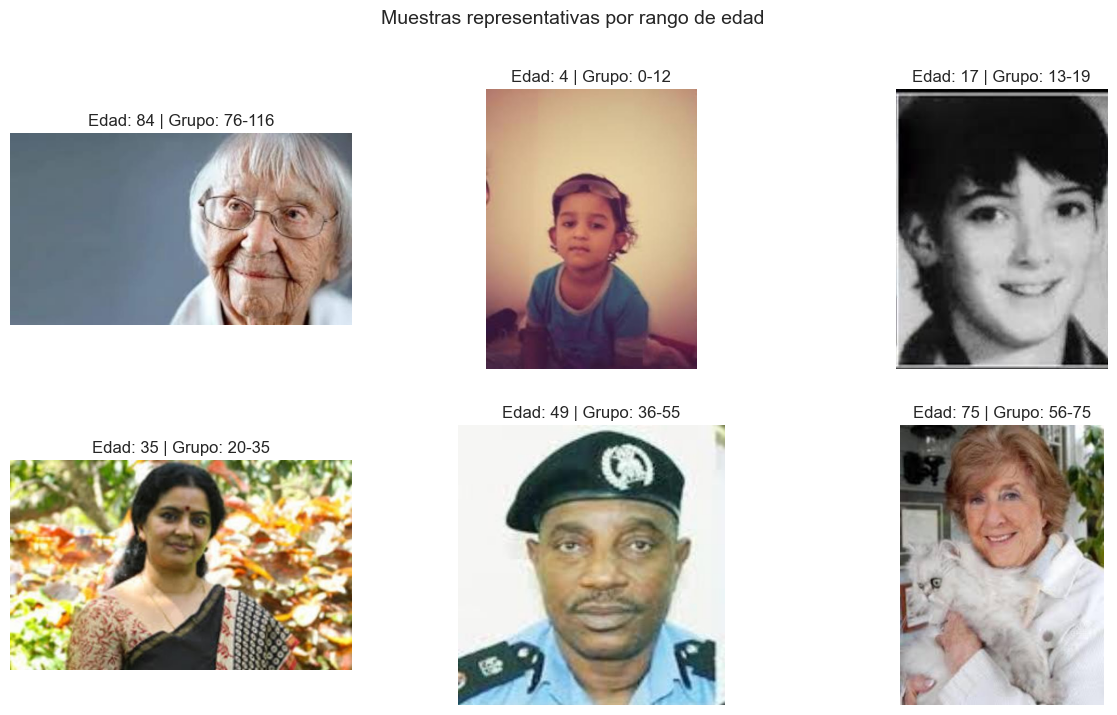

In [24]:
def plot_representative_samples_by_group(df, group_col='age_group', samples_per_group=1):
    available_groups = [group for group in df[group_col].dropna().unique()]
    n_cols = min(3, len(available_groups))
    n_rows = int(np.ceil(len(available_groups) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
    axes = np.atleast_1d(axes).flatten()

    for ax, group in zip(axes, available_groups):
        row = df[df[group_col] == group].sample(samples_per_group, random_state=random_state).iloc[0]
        with Image.open(row['path']) as image:
            ax.imshow(image.convert('RGB'))
        ax.set_title(f'Edad: {row["age"]} | Grupo: {group}')
        ax.axis('off')

    for ax in axes[len(available_groups):]:
        ax.axis('off')

    fig.suptitle('Muestras representativas por rango de edad', fontsize=14)
    plt.show()


plot_representative_samples_by_group(faces_df)
        


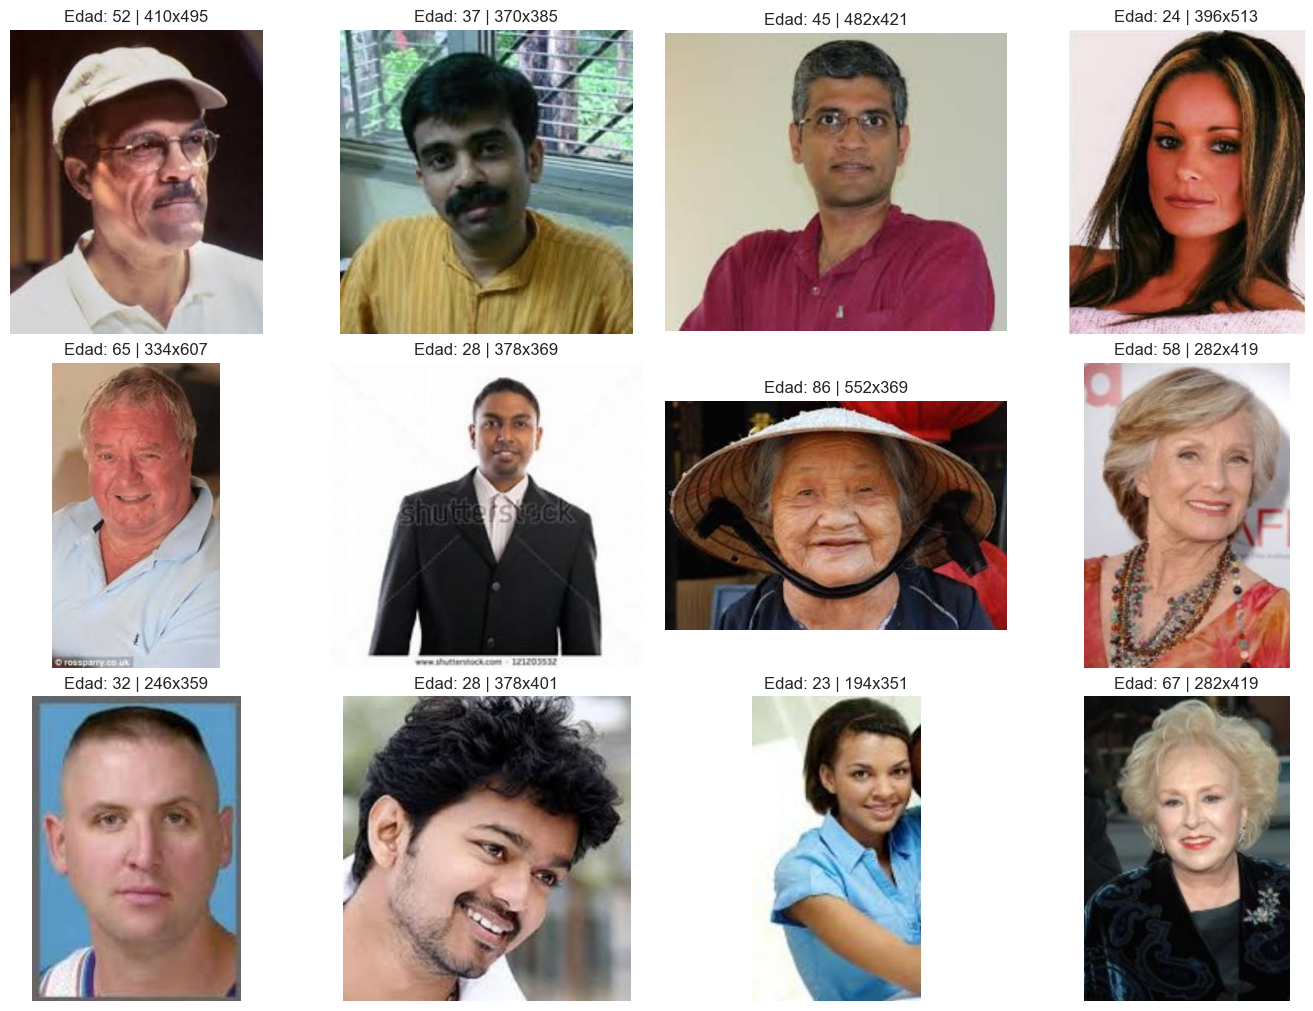

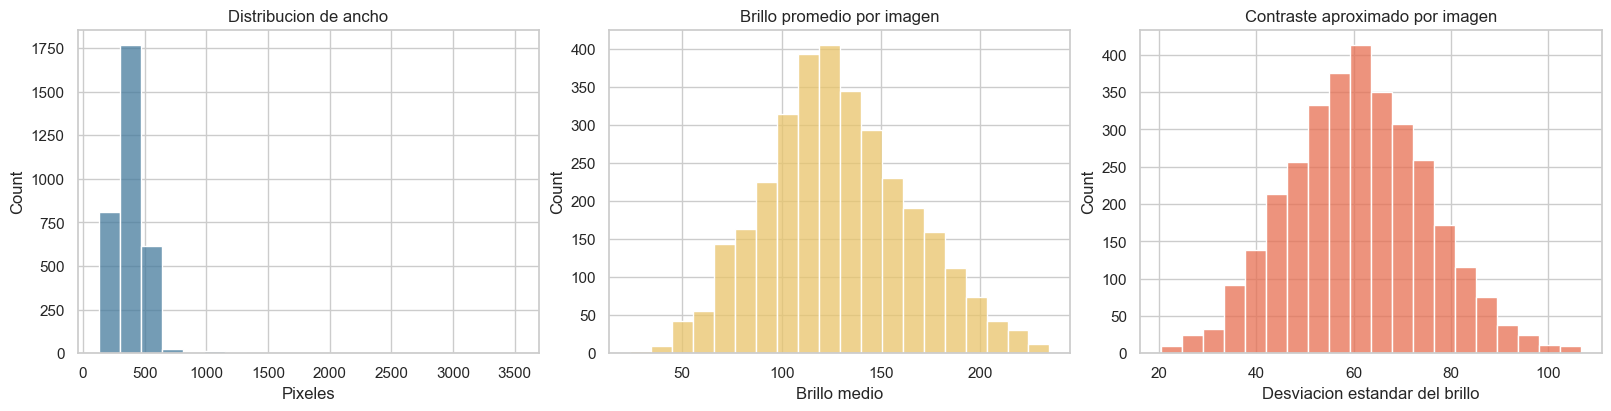

In [25]:
random_sample_df = faces_df.sample(min(12, len(faces_df)), random_state=random_state)

fig, axes = plt.subplots(3, 4, figsize=(14, 10), constrained_layout=True)
for ax, (_, row) in zip(axes.flatten(), random_sample_df.iterrows()):
    with Image.open(row['path']) as image:
        ax.imshow(image.convert('RGB'))
    ax.set_title(f'Edad: {row["age"]} | {row["width"]}x{row["height"]}')
    ax.axis('off')
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(16, 4), constrained_layout=True)

sns.histplot(faces_df['width'], bins=20, ax=axes[0], color='#457b9d')
axes[0].set_title('Distribucion de ancho')
axes[0].set_xlabel('Pixeles')

sns.histplot(faces_df['brightness_mean'], bins=20, ax=axes[1], color='#e9c46a')
axes[1].set_title('Brillo promedio por imagen')
axes[1].set_xlabel('Brillo medio')

sns.histplot(faces_df['brightness_std'], bins=20, ax=axes[2], color='#e76f51')
axes[2].set_title('Contraste aproximado por imagen')
axes[2].set_xlabel('Desviacion estandar del brillo')

plt.show()
        


In [26]:
print('Interpretacion de calidad y variabilidad de imagenes:')
print(f'- Numero de tamanos distintos detectados: {faces_df[["width", "height"]].drop_duplicates().shape[0]}.')
print(f'- Modo de color mas comun: {faces_df["mode"].mode().iat[0]}.')
print(f'- Brillo promedio global: {faces_df["brightness_mean"].mean():.2f}.')
print(f'- Variabilidad promedio del brillo: {faces_df["brightness_std"].mean():.2f}.')
print('- Si hay mucha variacion de brillo, tamano o encuadre, el problema de regresion se vuelve mas desafiante.')
print('- Estas visualizaciones justifican que en una fase posterior sera importante normalizar, redimensionar y posiblemente usar data augmentation.')
        


Interpretacion de calidad y variabilidad de imagenes:
- Numero de tamanos distintos detectados: 1239.
- Modo de color mas comun: RGB.
- Brillo promedio global: 128.24.
- Variabilidad promedio del brillo: 61.03.
- Si hay mucha variacion de brillo, tamano o encuadre, el problema de regresion se vuelve mas desafiante.
- Estas visualizaciones justifican que en una fase posterior sera importante normalizar, redimensionar y posiblemente usar data augmentation.


## 2.4 Hallazgos aplicados para la siguiente fase

A partir del analisis del dataset, estas son decisiones concretas que se pueden justificar para el problema 2 cuando se construya la CNN:

- usar un **DataLoader** para no cargar todo el dataset de imagenes al mismo tiempo
- trabajar por **batches de 32** imagenes, en lugar de intentar procesar miles a la vez
- evitar un redimensionamiento demasiado agresivo como `64x64` si las imagenes originales son bastante mayores
- aplicar **Flatten** despues de las capas convolucionales, no directamente sobre la imagen cruda

Esta parte todavia no entrena la CNN, pero deja argumentadas las decisiones de diseno que seguirian despues.
        


In [27]:
BATCH_SIZE_REFERENCE = 32
SIZE_REFERENCE = [64, 128, 224]


def tensor_memory_mb(num_images, img_size, channels=3, dtype_bytes=4):
    return (num_images * channels * img_size * img_size * dtype_bytes) / (1024 ** 2)


min_dimension = faces_df[['width', 'height']].min(axis=1)
median_width = faces_df['width'].median()
median_height = faces_df['height'].median()

cnn_preparation_df = pd.DataFrame(
    {
        'img_size': SIZE_REFERENCE,
        'pct_images_with_min_dim_ge_size': [
            (min_dimension >= size).mean() * 100 for size in SIZE_REFERENCE
        ],
        'batch32_tensor_mb': [
            tensor_memory_mb(BATCH_SIZE_REFERENCE, size) for size in SIZE_REFERENCE
        ],
        'full_dataset_tensor_gb': [
            tensor_memory_mb(len(faces_df), size) / 1024 for size in SIZE_REFERENCE
        ],
    }
)

print(f'Tamano mediano original del dataset: {median_width:.0f}x{median_height:.0f}')
display(cnn_preparation_df.round(2))
        


Tamano mediano original del dataset: 390x407


,img_size,pct_images_with_min_dim_ge_size,batch32_tensor_mb,full_dataset_tensor_gb
0,64,100.00,1.50,0.15
1,128,100.00,6.00,0.59
2,224,91.14,18.38,1.82


In [28]:
print('Interpretacion aplicada al problema 2:')
print('- DataLoader sera importante porque evita cargar todas las imagenes en memoria al mismo tiempo.')
print('- Un batch de 32 imagenes es una decision razonable para entrenar por lotes y controlar memoria.')
print('- La tabla anterior permite comparar cuanto crece el costo en memoria cuando aumenta el tamano de imagen.')
print('- Si una gran proporcion de imagenes tiene dimensiones superiores a 64x64, bajar todo a 64x64 puede eliminar detalles faciales utiles para estimar la edad.')
print('- Por eso, para la fase de CNN tiene sentido evaluar primero 128x128 antes de usar 64x64 como tamano final.')
print('- Flatten no debe aplicarse sobre la imagen original; debe aplicarse despues de las convoluciones, cuando ya existen mapas de caracteristicas relevantes.')
        


Interpretacion aplicada al problema 2:
- DataLoader sera importante porque evita cargar todas las imagenes en memoria al mismo tiempo.
- Un batch de 32 imagenes es una decision razonable para entrenar por lotes y controlar memoria.
- La tabla anterior permite comparar cuanto crece el costo en memoria cuando aumenta el tamano de imagen.
- Si una gran proporcion de imagenes tiene dimensiones superiores a 64x64, bajar todo a 64x64 puede eliminar detalles faciales utiles para estimar la edad.
- Por eso, para la fase de CNN tiene sentido evaluar primero 128x128 antes de usar 64x64 como tamano final.
- Flatten no debe aplicarse sobre la imagen original; debe aplicarse despues de las convoluciones, cuando ya existen mapas de caracteristicas relevantes.


## 3.0 Procesamiento de Datos


In [17]:

# ─── Configuración ─────────────────────────────────────────────
DATA_DIR   = Path("dataset")   # carpeta con train/ val/ test
IMG_SIZE   = 128            
BATCH_SIZE = 32
NUM_EPOCHS = 15
LR         = 1e-3
NUM_WORKERS = 2

# Reproducibilidad 
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Dispositivo 
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {DEVICE}")


#────────────────────────────────────────────────────────────────────────────────────────────
class AgeDataset(Dataset):
    """
    Dataset para imágenes con etiqueta de edad en el nombre de archivo.
    Formato esperado: [age]_[gender]_[race]_[datetime].jpg
    Ejemplo:          25_0_2_20170116174525125.jpg
    """

    def __init__(self, root_dir: Path, transform=None):
        """
        Args:
            root_dir  : ruta a la carpeta (ej: dataset/train)
            transform : transformaciones a aplicar a cada imagen
        """
        self.transform = transform

        # ── Paso 1: recolectar rutas y parsear etiquetas ───────────────────────
        # Esto ocurre UNA SOLA VEZ al crear el dataset.
        # Solo guardamos strings/números en memoria, NO píxeles.
        EXTENSIONS = {".jpg", ".jpeg", ".png"}
        self.samples = []  # lista de tuplas (path, age_float)

        for img_path in Path(root_dir).iterdir():
            if img_path.suffix.lower() not in EXTENSIONS:
                continue
            age = self._parse_age(img_path.name)
            if age is not None:            # descarta archivos con nombre inválido
                self.samples.append((img_path, float(age)))

        print(f"  [{root_dir.name}] {len(self.samples):,} imágenes cargadas")

    @staticmethod
    def _parse_age(filename: str):
        """
        Extrae la edad del nombre de archivo.
        '25_0_2_20170116.jpg'  →  25
        Retorna None si el formato no coincide.
        """
        match = re.match(r'^(\d+)_', filename)
        if match:
            age = int(match.group(1))
            if 0 <= age <= 116:            # filtro de sanidad
                return age
        return None

    # ── Los 2 métodos obligatorios ─────────────────────────────────────────────

    def __len__(self):
        """PyTorch llama esto para saber cuántos ejemplos hay."""
        return len(self.samples)

    def __getitem__(self, idx):
        """
        PyTorch llama esto para obtener el ejemplo número `idx`.
        Este es el único momento en que tocamos el disco.

        Retorna:
            image  : Tensor [C, H, W]  (float32)
            age    : Tensor escalar     (float32)
        """
        img_path, age = self.samples[idx]

        # Leer imagen del disco
        image = Image.open(img_path).convert("RGB")

        # Aplicar transformaciones (resize, normalizar, augmentations...)
        if self.transform:
            image = self.transform(image)

        # La etiqueta debe ser float32 para regresión con MSELoss
        return image, torch.tensor(age, dtype=torch.float32)
     


Usando dispositivo: cpu


In [18]:
IMG_SIZE = 128

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

### Redimensionamiento y normalización

Las imágenes presentan diferentes tamaños, por lo que se redimensionan a 128x128 píxeles para asegurar consistencia en la entrada del modelo.

Posteriormente, se normalizan utilizando los valores estándar de ImageNet, lo que permite estabilizar el entrenamiento de la red neuronal.

### Data augmentation

Se aplicaron técnicas de data augmentation únicamente al conjunto de entrenamiento, incluyendo:

- Volteo horizontal aleatorio
- Variaciones de brillo y contraste

Esto se justifica debido a la alta variabilidad del dataset en condiciones de iluminación, pose y calidad de imagen, lo que ayuda a mejorar la capacidad de generalización del modelo.

### División del dataset

La proporción utilizada  usando el notebook `data_split.ipynb` fue aproximadamente:

- 70% para train
- 15% para val
- 15% para test

Esta división permite:

- **Entrenamiento (train):** ajustar los parámetros del modelo CNN.
- **Validación (val):** evaluar el desempeño durante el entrenamiento y detectar overfitting.
- **Prueba (test):** medir el rendimiento final del modelo con datos no vistos.

El uso de una mayor proporción en el conjunto de entrenamiento se justifica porque los modelos de deep learning requieren una cantidad considerable de datos para aprender patrones complejos. Por otro lado, separar conjuntos de validación y prueba permite obtener una evaluación más confiable y evitar sesgos en la medición del desempeño del modelo.

La partición se realizó previamente organizando las imágenes en carpetas (`train/`, `val/`, `test/`), por lo que no fue necesario aplicar funciones adicionales de división dentro del código.

In [16]:
train_dataset = AgeDataset("dataset/train", transform=train_transform)
val_dataset   = AgeDataset("dataset/val",   transform=val_transform)
test_dataset  = AgeDataset("dataset/test",  transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

## Pipeline de preprocesamiento

Se implementó un pipeline de preprocesamiento reproducible para el manejo de las imágenes utilizando PyTorch.

**El flujo de datos:**

El flujo de procesamiento de los datos sigue una secuencia organizada donde las imágenes se leen desde el disco, luego son gestionadas por un Dataset personalizado, posteriormente se les aplican transformaciones de preprocesamiento y finalmente son agrupadas en batches mediante el DataLoader para ser utilizadas por el modelo.

- **Dataset:** se encarga de leer las imágenes desde disco y extraer la edad a partir del nombre del archivo.
- **Transformaciones:** se aplican operaciones de redimensionamiento, normalización y data augmentation.
- **DataLoader:** agrupa los datos en batches y optimiza la carga en memoria durante el entrenamiento.
